In [1]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import time
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
import itertools
from matplotlib.patches import Patch

from test_sol_reweight import load_items, get_eda_params, run_eda_pass, save_pass_results, select_test_ref, gen_aspi

In [2]:
# set up EDA parameters

trial_id = 8
stimuli_dir = Path("card_game/stimuli")
output_dir = Path("data/eda_results/")
output_dir.mkdir(parents=True, exist_ok=True)
items = load_items(stimuli_dir=stimuli_dir, trial_id=trial_id)
params = get_eda_params(items)
n_obj = params["n_obj"]
if_rank = True
temp = 0.3

with open(f"card_game/eda_results/eda_trial{trial_id}.pkl", "rb") as f:
    results_actual = pickle.load(f)
pf_actual = results_actual["converged_pf_table"][-1]

# percentile = np.array([10, 100, 100, 50, 50])
# ref_sol = select_test_ref(pf_actual, percentile)
ref_sol = np.array([50.0, 90.0, 160.0, 80.0, 100.0])
aspi = gen_aspi(ref_sol, items)
unit_aspi = aspi / (np.linalg.norm(aspi) + 1e-12)

In [ ]:
# run EDA

run_name = "loop5_2"
eda_results = run_eda_pass(
    items=items,
    params=params,
    seed=1127,
    aspi=unit_aspi,
    if_rank=if_rank,
    temp=temp,
)
pkl_path = save_pass_results(run_name, eda_results, output_dir)
pf = eda_results["converged_pf_table"][-1]

history = {
    "trial_id": trial_id,
    # "percentile": percentile,
    "original_aspi": ref_sol,
    "normalized_aspi": aspi,
    "unit_aspi": unit_aspi,
    "if_rank": if_rank,
    "temp": temp,
}
history_path = output_dir / f"history_{run_name}.pkl"
with open(history_path, "wb") as f:
    pickle.dump(history, f)

In [3]:
### ---- load run data ---

run_name = "loop5_2"
pkl_path = output_dir / f"eda_human_reweight_{run_name}.pkl"
with open(pkl_path, "rb") as f:
    eda_results = pickle.load(f)
pf = eda_results["converged_pf_table"][-1]
history_path = output_dir / f"history_{run_name}.pkl"
with open(history_path, "rb") as f:
    history = pickle.load(f)

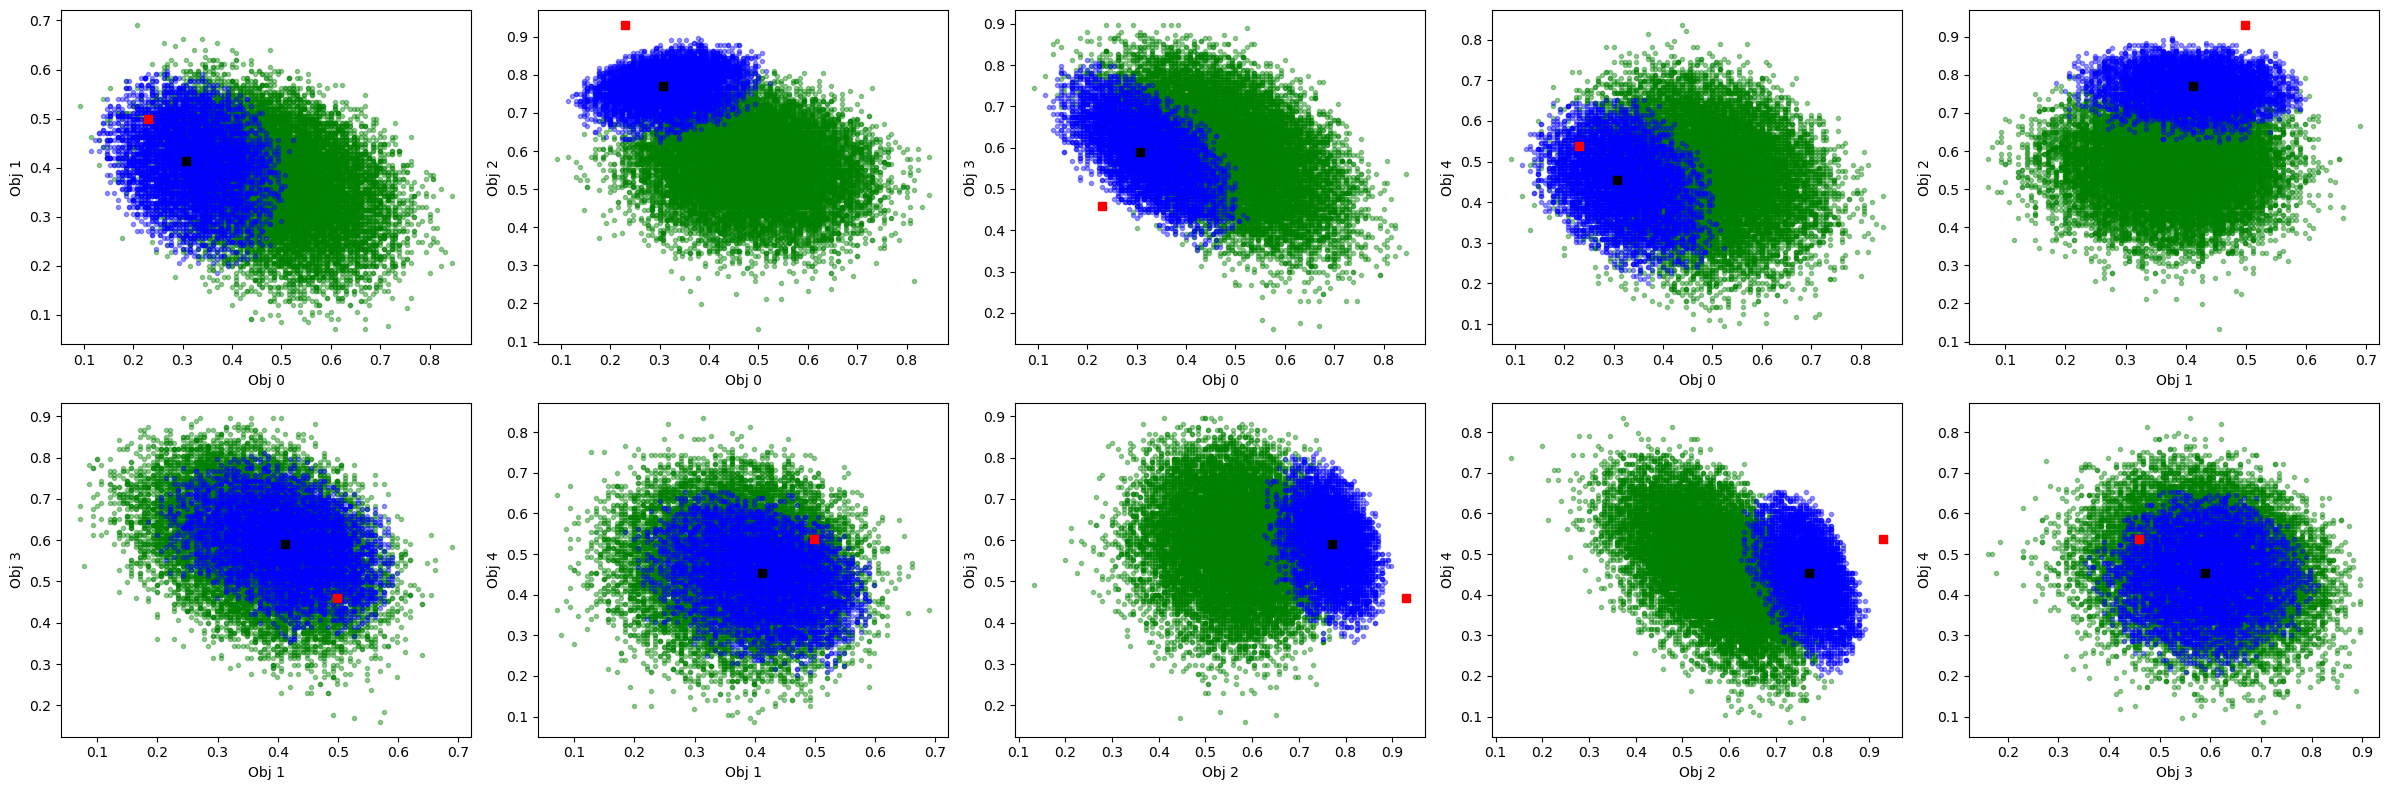

In [6]:
# visualize pf 
aspi = history["normalized_aspi"]
pf_norm = gen_aspi(pf, items)
pf_actual_norm = gen_aspi(pf_actual, items)

center = np.median(pf, axis=0)
dist = np.linalg.norm(pf - center, axis=1)
center_sol = pf[dist.argmin()]
center_sol_norm = gen_aspi(center_sol, items)

objective_pairs = list(itertools.combinations(range(n_obj), 2))
n_pairs = len(objective_pairs)
n_cols = min(5, n_pairs)
n_rows = int(np.ceil(n_pairs / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()
for ax, (a, b) in zip(axes, objective_pairs):
    ax.plot(pf_actual_norm[:, a], pf_actual_norm[:, b], "go", alpha=0.4, markersize=3, label="Actual PF")
    ax.plot(pf_norm[:, a], pf_norm[:, b], "bo", alpha=0.4, markersize=3, label="Guided PF")
    ax.plot(aspi[a], aspi[b], "rs", alpha=1, markersize=6, label="Aspiration")
    ax.plot(center_sol_norm[a], center_sol_norm[b], "ks", alpha=1, markersize=6, label="Center")
    ax.set_xlabel(f"Obj {a}")
    ax.set_ylabel(f"Obj {b}")
    # ax.set_xlim(0.1, 0.9)
    # ax.set_ylim(0.1, 0.9)
fig.tight_layout()
plt.show()


In [5]:
# keep only high density region of pf
## may be redundant with applying NearestNeighbors when fitting local quadratic regression

nbrs = NearestNeighbors(n_neighbors=min(10+1, pf.shape[0])).fit(pf)
dist_nbrs, _ = nbrs.kneighbors(pf)
sparse_score = dist_nbrs[:, 1:].mean(axis=1)
cutoff = np.quantile(sparse_score, 0.8)
keep = sparse_score <= cutoff
pf = pf[keep]

In [ ]:
# extract pf to csv (columns o0..o{n_obj-1})

OUT_DIR = Path("data/pf")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OBJ_COLS = [f"o{i}" for i in range(n_obj)]
df = pd.DataFrame(pf, columns=OBJ_COLS).astype(int)
out_name = pkl_path.stem.replace("eda_human_reweight_", "", 1) + ".csv"
out_path = OUT_DIR / out_name
df.to_csv(out_path, index=False)
print(f"Saved {len(df)} points → {out_path}")

In [7]:
# --- load pf data ---
trial_id = 8
run_name = "loop5_2"
OUT_DIR = Path("data/pf")
out_path = OUT_DIR / f"{run_name}.csv"
df = pd.read_csv(out_path)

In [9]:
# set up MRS parameters

data = df.values.astype(float)
obj_names = list(df.columns)
N, d  = data.shape

iqr = np.percentile(data, 75, axis=0) - np.percentile(data, 25, axis=0)
nadir = data.min(axis=0)
ideal = data.max(axis=0)

K = 100
SMOOTH = 80
EPSILON = 0.10
OBJ_COLORS = ["#4E79A7", "#F28E2B", "#59A14F", "#E15759", "#B07AA1"]

In [10]:
print(f"Objectives : {obj_names}")
print(f"Points     : {N:,}")
print(f"\nPer-objective summary:")
summary = pd.DataFrame({
    'min':    nadir.round(1),
    'median': np.median(data, axis=0).round(1),
    'max':    ideal.round(1),
    'IQR':    iqr.round(2),
}, index=obj_names)
display(summary)

Objectives : ['o0', 'o1', 'o2', 'o3', 'o4']
Points     : 5,075

Per-objective summary:


,min,median,max,IQR
o0,35.0,61.0,88.0,14.0
o1,46.0,78.0,104.0,16.0
o2,114.0,137.0,155.0,10.0
o3,66.0,97.0,126.0,15.0
o4,56.0,89.0,115.0,16.0


In [11]:
# obtain query point

# PERCENTILE = None
# if PERCENTILE is not None:
#     target = np.array([np.percentile(data[:, i], p)
#                             for i, p in enumerate(PERCENTILE)])
#     query_label = "percentile"
#     print("Target (percentile):")
#     for n, p, v in zip(obj_names, PERCENTILE, target):
#         print(f"  {n}: {p:.0f}th → {v:.1f}")
# else:
#     target = np.median(data, axis=0)
#     query_label = "median"
#     print("Target (median):")
#     for n, v in zip(obj_names, target):
#         print(f"  {n}: {v:.1f}")
# dists = np.abs((data - target) / iqr).sum(axis=1)
# query_idx = int(np.argmin(dists))
# query_pt = data[query_idx]

# closest to reference
ref_sol = history["original_aspi"]
dists = np.abs((data - ref_sol) / iqr).sum(axis=1)
query_idx = int(np.argmin(dists))
query_pt = data[query_idx]

# median of pf
# target = np.median(data, axis=0)
# dists = np.abs((data - target) / iqr).sum(axis=1)
# query_idx = int(np.argmin(dists))
# query_pt = data[query_idx]

# closest to previous reference
# target = np.array([27.0, 83.0, 60.0])
# dists = np.abs((data - target) / iqr).sum(axis=1)
# query_idx = int(np.argmin(dists))
# query_pt = data[query_idx]

In [ ]:
# visualize pf with query point
aspi = history["normalized_aspi"]
pf_norm = gen_aspi(pf, items)
pf_actual_norm = gen_aspi(pf_actual, items)
query_pt_norm = gen_aspi(query_pt, items)

center = np.median(pf, axis=0)
dist = np.linalg.norm(pf - center, axis=1)
center_sol = pf[dist.argmin()]
center_sol_norm = gen_aspi(center_sol, items)

objective_pairs = list(itertools.combinations(range(n_obj), 2))
n_pairs = len(objective_pairs)
n_cols = min(5, n_pairs)
n_rows = int(np.ceil(n_pairs / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()
for ax, (a, b) in zip(axes, objective_pairs):
    ax.plot(pf_actual_norm[:, a], pf_actual_norm[:, b], "go", alpha=0.4, markersize=3, label="Actual PF")
    ax.plot(pf_norm[:, a], pf_norm[:, b], "bo", alpha=0.4, markersize=3, label="Guided PF")
    ax.plot(aspi[a], aspi[b], "rs", alpha=1, markersize=6, label="Aspiration")
    ax.plot(center_sol_norm[a], center_sol_norm[b], "ks", alpha=1, markersize=6, label="Center")
    ax.plot(query_pt_norm[a], query_pt_norm[b], "s", color="yellow", alpha=1, markersize=6, label="Query")
    ax.set_xlabel(f"Obj {a}")
    ax.set_ylabel(f"Obj {b}")
    # ax.set_xlim(0.1, 0.9)
    # ax.set_ylim(0.1, 0.9)
fig.tight_layout()
plt.show()

In [ ]:
# compure MRS

poly = PolynomialFeatures(degree=2, include_bias=True)

print(f"Building {K}-NN graph ...", end=" ", flush=True)
t0 = time.time()
nn = NearestNeighbors(n_neighbors=K + 1).fit(data / iqr)
_, nn_indices = nn.kneighbors(data / iqr) # nn_indices has shape (N, K+1)
print(f"{time.time()-t0:.1f}s")

print(f"Fitting local quadratic regressions at {N:,} points ...", end=" ", flush=True)
t0    = time.time()
betas = np.zeros((N, d, d))

for idx in range(N):
    nbrs = data[nn_indices[idx, 1:]] - data[idx] # nbrs has shape (K, d)
    for j in range(d):
        input_cols = [c for c in range(d) if c != j]
        X_poly     = poly.fit_transform(nbrs[:, input_cols]) # X_poly is the design matrix
        coef, _, _, _ = np.linalg.lstsq(X_poly, nbrs[:, j], rcond=None) # for d = 5, X_poly is (K, 15), nbrs[:, j] is (K, ), coef is (15, )
        for pos, i in enumerate(input_cols):
            betas[idx, i, j] = coef[pos + 1] * iqr[i] / iqr[j] # only linear coef are extraced for MRS

print(f"{time.time()-t0:.1f}s")
print("Done.")

In [ ]:
# plot bar chart of MRS

fig, axes = plt.subplots(1, d, figsize=(4 * d, 5), facecolor="#FAFAF8", squeeze=False)
fig.suptitle(
    f"Tradeoff rates at the query point\n"
    + "  ".join(f"{n}={v:.1f}" for n, v in zip(obj_names, query_pt))
    + "\n(% of IQR(oⱼ) change per 1% IQR improvement in oᵢ)",
    fontsize=10, fontweight="bold", y=1.03,
)
for i, ax in enumerate(axes[0]):
    others = [j for j in range(d) if j != i]
    vals   = [betas[query_idx, i, j] for j in others]
    bars   = ax.bar(np.arange(len(others)), vals,
                    color=[OBJ_COLORS[j] for j in others],
                    alpha=0.85, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val - 0.02,
                f"{val:.3f}", ha="center", va="top",
                fontsize=9, fontweight="bold", color="white")
    ax.axhline(0, color="red", lw=1.2, alpha=0.8)
    ax.set_xticks(np.arange(len(others)))
    ax.set_xticklabels([obj_names[j] for j in others], fontsize=11)
    ax.set_title(f"Improving {obj_names[i]}", fontsize=11, fontweight="bold")
    ax.set_ylabel("% of IQR change" if i == 0 else "", fontsize=9)
    ax.set_ylim(-1.5, 0.2)
    ax.set_facecolor("#F7F7F5")
    ax.grid(True, axis="y", lw=0.3, color="#DDDDDD")
    ax.set_xlim(-0.5, len(others) - 0.5)
plt.tight_layout()
plt.show()

In [ ]:
# plot validity
nbrs_q = data[nn_indices[query_idx, 1:]] - data[query_idx]

radii_pct  = np.full((d, d), np.nan)
radii_raw  = np.full((d, d), np.nan)

for j in range(d):
    input_cols = [c for c in range(d) if c != j]
    feat_names = [f"x{p}" for p in range(len(input_cols))]
    X_poly     = poly.fit_transform(nbrs_q[:, input_cols])
    all_names  = list(poly.get_feature_names_out(feat_names))
    coef, _, _, _ = np.linalg.lstsq(X_poly, nbrs_q[:, j], rcond=None)

    for pos, i in enumerate(input_cols):
        b    = coef[pos + 1]
        c_ii = coef[all_names.index(f"x{pos}^2")]
        if abs(b) < 1e-8 or abs(c_ii) < 1e-10:
            radii_pct[i,j] = np.inf
            radii_raw[i,j] = np.inf
        else:
            dr = EPSILON * abs(b) / abs(c_ii)
            radii_raw[i,j] = dr
            radii_pct[i,j] = dr / iqr[i] * 100

print(f"Validity radii at query point  (ε={EPSILON:.0%})")
df_validity = pd.DataFrame(radii_pct.round(1), index=obj_names, columns=obj_names)
display(df_validity)

pct_vals, raw_vals, colors, labels = [], [], [], []
for i in range(d):
    for j in range(d):
        if i == j or np.isnan(radii_pct[i, j]): continue
        pct_vals.append(min(radii_pct[i, j], 200))
        raw_vals.append(min(radii_raw[i, j], 999))
        colors.append(OBJ_COLORS[i])
        labels.append(f"{obj_names[i]}→{obj_names[j]}")

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#FAFAF8")
bars = ax.bar(np.arange(len(pct_vals)), pct_vals, color=colors,
              alpha=0.85, edgecolor="white", linewidth=0.5)
for bar, raw, pct in zip(bars, raw_vals, pct_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, min(pct, 195) + 1.5,
            f"{raw:.1f}" if raw < 999 else ">999",
            ha="center", va="bottom", fontsize=7.5,
            color="#333333", rotation=90)
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Validity radius (% of IQR of reference objective)", fontsize=10)
ax.set_title(
    f"Validity range — query point  (ε={EPSILON:.0%})\n"
    "Bar height = step size where prediction error = ε  |  "
    "Number = raw units  |  Colour = reference objective",
    fontsize=10, fontweight="bold")
ax.set_ylim(0, 220)
ax.set_facecolor("#F7F7F5")
ax.grid(True, axis="y", lw=0.3, color="#DDDDDD")
handles = [Patch(color=OBJ_COLORS[i], alpha=0.85, label=obj_names[i])
           for i in range(d)]
ax.legend(handles=handles, fontsize=9, loc="upper left", ncol=3)
plt.tight_layout()
plt.show()

In [ ]:
# visualize pf 3D
%matplotlib widget
from mpl_toolkits.mplot3d import Axes3D

query_pt_norm = gen_aspi(query_pt, items)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
ax.plot(pf_actual_norm[:,0], pf_actual_norm[:,1], pf_actual_norm[:,2], 'go', alpha=0.5, markersize=3)
ax.plot(pf_norm[:,0], pf_norm[:,1], pf_norm[:,2], 'bo', alpha=0.5, markersize=3)
ax.plot(aspi[0], aspi[1], aspi[2], 'rs', markersize=6)
ax.plot(center_sol_norm[0], center_sol_norm[1], center_sol_norm[2], 'ks', markersize=6)
ax.plot(query_pt_norm[0], query_pt_norm[1], query_pt_norm[2], 's', color='yellow', markersize=6)
ax.set_xlabel('Obj 0')
ax.set_ylabel('Obj 1')
ax.set_zlabel('Obj 2')
plt.show()